In [1]:
from sklearn import datasets
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [2]:
#DATA
digits = datasets.load_digits()
#digits.data has shape (1797, 64)
#digits.target has shape (1797,)

# unsupervised

In [3]:
#transforming to 2 dimensions
embedding = Isomap(n_neighbors=6, n_components=2)
dig_2D = embedding.fit_transform(digits.data)

C:\Users\giuli\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\giuli\anaconda3\Lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


Text(0.5, 1.0, 'digits embedded in 2D manifold')

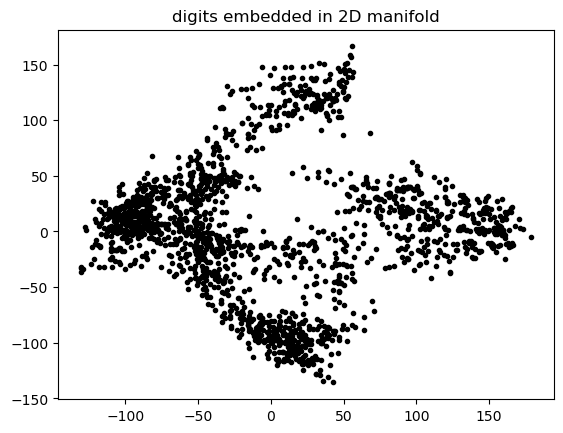

In [4]:
plt.plot(dig_2D[:, 0], dig_2D[:, 1], ".k")
plt.title("digits embedded in 2D manifold")

adding labels just to see (but it's still unsupervised now)

Text(0.5, 1.0, 'digits in 2D with labels')

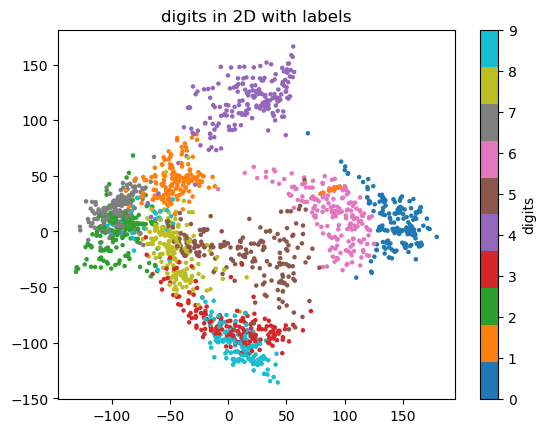

In [5]:
plt.scatter(dig_2D[:, 0], dig_2D[:, 1], c=digits.target, cmap="tab10", s=5)
plt.colorbar(label="digits")
plt.title("digits in 2D with labels")

# supervised

splitting dataset: 
- 80% as training set
- 20% as a test set

In [6]:
split_dig = train_test_split(digits.data, train_size=0.8, random_state=0)
split_targ = train_test_split(digits.target, train_size=0.8, random_state=0)
#[0] is 80% training
#[1] is 20% test

In [7]:
#TRAINING
classifier = LogisticRegression(max_iter=2000).fit(split_dig[0], split_targ[0])
train_predictions = classifier.predict(split_dig[0])
print("training score:", classifier.score(split_dig[0], split_targ[0]))

training score: 1.0


In [8]:
#TEST
test_predictions = classifier.predict(split_dig[1])
print("test score:", classifier.score(split_dig[1], split_targ[1]))

test score: 0.9694444444444444


In [9]:
print("confusion matrix for training:\n", confusion_matrix(split_targ[0], train_predictions))

confusion matrix for training:
 [[151   0   0   0   0   0   0   0   0   0]
 [  0 147   0   0   0   0   0   0   0   0]
 [  0   0 141   0   0   0   0   0   0   0]
 [  0   0   0 154   0   0   0   0   0   0]
 [  0   0   0   0 151   0   0   0   0   0]
 [  0   0   0   0   0 142   0   0   0   0]
 [  0   0   0   0   0   0 137   0   0   0]
 [  0   0   0   0   0   0   0 140   0   0]
 [  0   0   0   0   0   0   0   0 135   0]
 [  0   0   0   0   0   0   0   0   0 139]]


In [10]:
print("confusion matrix for test:\n", confusion_matrix(split_targ[1], test_predictions))

confusion matrix for test:
 [[27  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  0  0  0  0  0  1  0]
 [ 0  0 35  1  0  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0  0  0]
 [ 0  0  0  0 29  0  0  1  0  0]
 [ 0  0  0  0  0 38  0  0  0  2]
 [ 0  1  0  0  0  0 43  0  0  0]
 [ 0  0  0  0  1  0  0 38  0  0]
 [ 0  2  1  0  0  0  0  0 36  0]
 [ 0  0  0  0  0  1  0  0  0 40]]


- 8 is the most confused
- 8 is mostly confused with 1
- 5 is mostly confused with 9

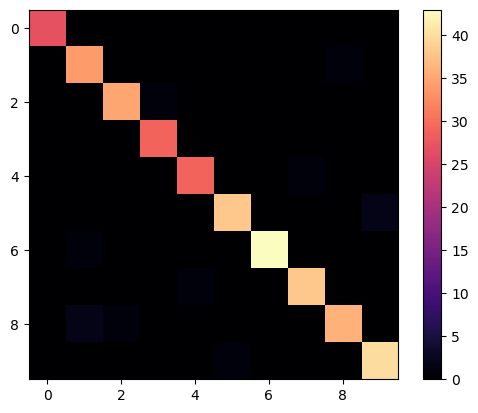

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)
im = ax.imshow(confusion_matrix(split_targ[1], test_predictions), cmap="magma")
fig.colorbar(im, ax=ax)